# Financial Market Analysis - Industry Case Study
**Objective:** To analyze stock performance, risk-reward profiles, and trading signals using Python.
**Tools:** Pandas, NumPy, Seaborn, Matplotlib.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### Set aesthetics

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

##### Load Data

In [5]:
df = pd.read_csv('stocks.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Ticker', 'Date'])

###  How to check the basic info and data types of the CSV?

In [35]:
print("--- Dataset Information ---")
df.info()

df.head()

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 0 to 61
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Ticker             62 non-null     object        
 1   Date               62 non-null     datetime64[ns]
 2   Open               62 non-null     float64       
 3   High               62 non-null     float64       
 4   Low                62 non-null     float64       
 5   Close              62 non-null     float64       
 6   Adj Close          62 non-null     float64       
 7   Volume             62 non-null     int64         
 8   Daily_Return       61 non-null     float64       
 9   MA50               13 non-null     float64       
 10  MA200              0 non-null      float64       
 11  Cumulative_Return  61 non-null     float64       
 12  Daily_Range        62 non-null     float64       
 13  EMA9               62 non-null     float64  

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,MA50,...,Cumulative_Return,Daily_Range,EMA9,EMA15,Signal,Action,Crossover,Intraday_Vol,Range,Cum_Return
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600,NaN,NaN,...,NaN,4.589996,154.649994,154.649994,0,NaN,NaN,3.046997,4.589996,1.000000
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100,-0.017653,NaN,...,0.982347,3.410004,153.133330,153.193996,0,-1.0,0.0,2.255741,3.410004,0.982347
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100,-0.006912,NaN,...,0.975558,3.910004,152.205734,152.313901,0,0.0,0.0,2.599391,3.910004,0.975558
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700,0.000928,NaN,...,0.976463,2.119995,151.800673,151.920037,0,0.0,0.0,1.420718,2.119995,0.976463
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000,0.018807,NaN,...,0.994827,3.339996,152.410303,152.415316,0,0.0,0.0,2.213091,3.339996,0.994827


### 1. Q: How do you check the total number of rows and columns?

In [10]:
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset has 248 rows and 12 columns.


### 2. Q:How do you list all the unique stock tickers in the file?

In [11]:
tickers = df['Ticker'].unique()
print("Unique Stocks:", tickers)

Unique Stocks: ['AAPL' 'GOOG' 'MSFT' 'NFLX']


### 3. Q: How do you see the summary statistics (mean, min, max) for all numeric columns?

In [12]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,MA50,MA200,Cumulative_Return
count,248,248.000000,248.000000,248.000000,248.000000,248.000000,2.480000e+02,244.000000,52.000000,0.0,244.000000
mean,2023-03-22 22:27:05.806451712,215.252093,217.919662,212.697452,215.381674,215.362697,3.208210e+07,0.000714,213.901964,NaN,0.970841
min,2023-02-07 00:00:00,89.540001,90.129997,88.860001,89.349998,89.349998,2.657900e+06,-0.074417,99.230800,NaN,0.806612
25%,2023-03-01 00:00:00,135.235004,137.440004,134.822495,136.347498,136.347498,1.714180e+07,-0.010764,142.492675,NaN,0.911296
50%,2023-03-22 12:00:00,208.764999,212.614998,208.184998,209.920006,209.920006,2.734000e+07,-0.000741,214.715601,NaN,0.972973
75%,2023-04-14 00:00:00,304.177505,307.565002,295.437500,303.942505,303.942505,4.771772e+07,0.010608,288.981450,NaN,1.028844
max,2023-05-05 00:00:00,372.410004,373.829987,361.739990,366.829987,366.829987,1.133164e+08,0.090065,328.515400,NaN,1.161048
std,NaN,91.691315,92.863023,90.147881,91.461989,91.454750,2.233590e+07,0.019026,90.070691,NaN,0.079180



### 4. Q: How do you check if there are any missing (NaN) values in the dataset?

In [13]:
df.isnull().sum()

Ticker                 0
Date                   0
Open                   0
High                   0
Low                    0
Close                  0
Adj Close              0
Volume                 0
Daily_Return           4
MA50                 196
MA200                248
Cumulative_Return      4
dtype: int64

### 5. Q: How do you filter and view data for only one specific stock (e.g., 'AAPL')?

In [14]:
aapl_df = df[df['Ticker'] == 'AAPL']
aapl_df.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,MA50,MA200,Cumulative_Return
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600,NaN,NaN,NaN,NaN
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100,-0.017653,NaN,NaN,0.982347
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100,-0.006912,NaN,NaN,0.975558
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700,0.000928,NaN,NaN,0.976463
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000,0.018807,NaN,NaN,0.994827


### 6. Q: What is the highest 'High' price ever recorded in this dataset?

In [15]:
max_high = df['High'].max()
print(f"Maximum High Price: {max_high}")

Maximum High Price: 373.8299865722656


### 7. Q: How do you calculate the average 'Volume' for each ticker?

In [16]:
avg_volume = df.groupby('Ticker')['Volume'].mean()
print(avg_volume)

Ticker
AAPL    6.028296e+07
GOOG    3.072537e+07
MSFT    3.084835e+07
NFLX    6.471732e+06
Name: Volume, dtype: float64


### 8. Q: How do you create a new column called 'Daily_Range' (High minus Low)?

In [17]:
df['Daily_Range'] = df['High'] - df['Low']

### 9. Q: How do you find the specific date when a stock had its lowest 'Close' price?

In [18]:
min_row = df.loc[df['Close'].idxmin()]
print(f"Lowest price was on {min_row['Date']} for ticker {min_row['Ticker']}")

Lowest price was on 2023-02-24 00:00:00 for ticker GOOG


### 10. Q: How do you count how many days of data are available for each ticker?

In [19]:
df['Ticker'].value_counts()

Ticker
AAPL    62
GOOG    62
MSFT    62
NFLX    62
Name: count, dtype: int64

### 11. Q:Which stock is the most "Risky" based on Standard Deviation?

In [28]:
volatility = df.groupby('Ticker')['Daily_Return'].std().sort_values(ascending=False)
print("--- Volatility (Risk) Ranking ---")
print(volatility)

--- Volatility (Risk) Ranking ---
Ticker
AAPL    0.014152
Name: Daily_Return, dtype: float64


### 12. Q: How many "Buy Signals" were generated for each stock?

In [29]:
buy_counts = df[df['Action'] == 1].groupby('Ticker').size()
print("--- Total Buy Signals Per Ticker ---")
print(buy_counts)

--- Total Buy Signals Per Ticker ---
Series([], dtype: int64)


### 13. Q:What is the "Intraday Range" (High - Low) distribution?

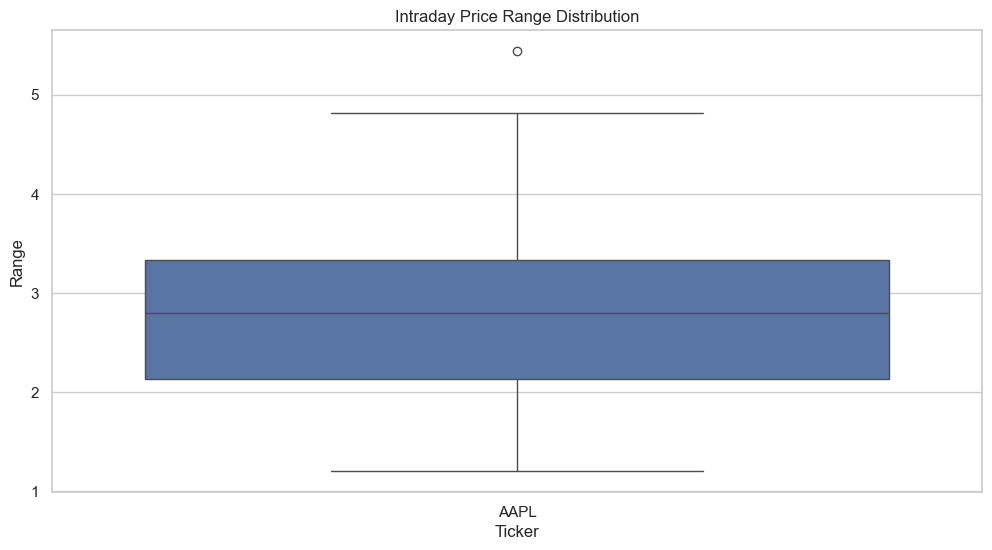

In [30]:
df['Range'] = df['High'] - df['Low']
sns.boxplot(x='Ticker', y='Range', data=df)
plt.title("Intraday Price Range Distribution")
plt.show()

### 14. Q:: Detecting "Volume Spikes"

In [32]:
avg_vol = df.groupby('Ticker')['Volume'].transform('mean')
spikes = df[df['Volume'] > (avg_vol * 2)]
print("--- Days with Volume Spikes ---")
print(spikes[['Date', 'Ticker', 'Volume']].head())

--- Days with Volume Spikes ---
Empty DataFrame
Columns: [Date, Ticker, Volume]
Index: []


### 15. Q: How do you plot a simple line chart of 'Close' prices for 'AAPL'?

<Axes: title={'center': 'AAPL Closing Prices'}, xlabel='Date'>

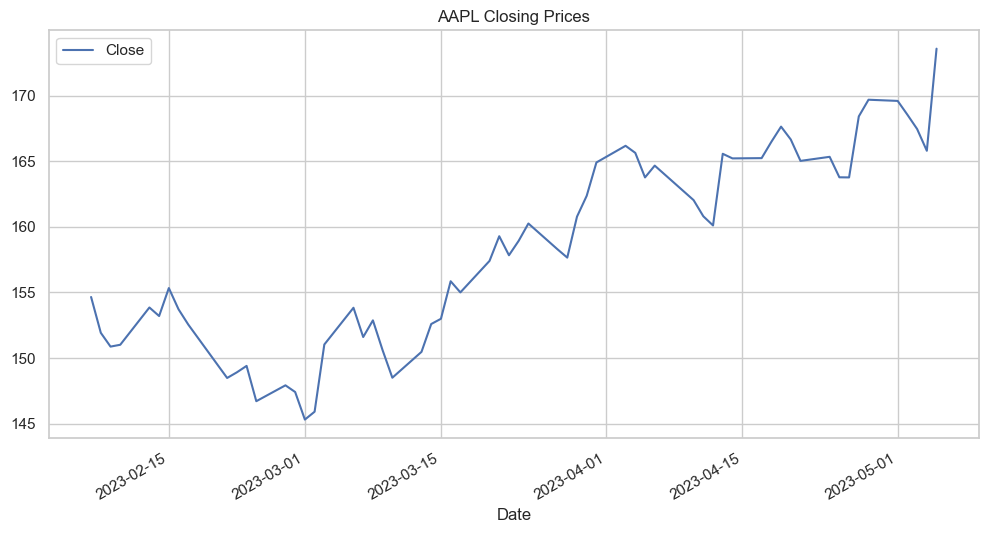

In [20]:
df[df['Ticker'] == 'AAPL'].plot(x='Date', y='Close', title='AAPL Closing Prices')

### 16. Q: How do you create a Bar Chart showing the total volume traded for each ticker?

Text(0, 0.5, 'Total Volume')

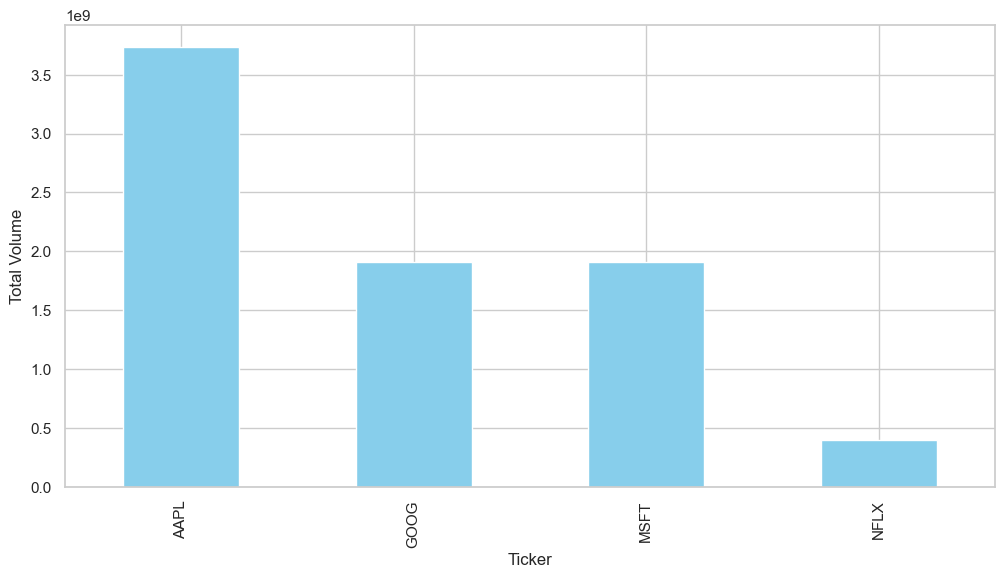

In [21]:
df.groupby('Ticker')['Volume'].sum().plot(kind='bar', color='skyblue')
plt.ylabel('Total Volume')

### 17. Q: How do you draw a Histogram to see the distribution of 'Close' prices?

Text(0.5, 1.0, 'Distribution of Closing Prices')

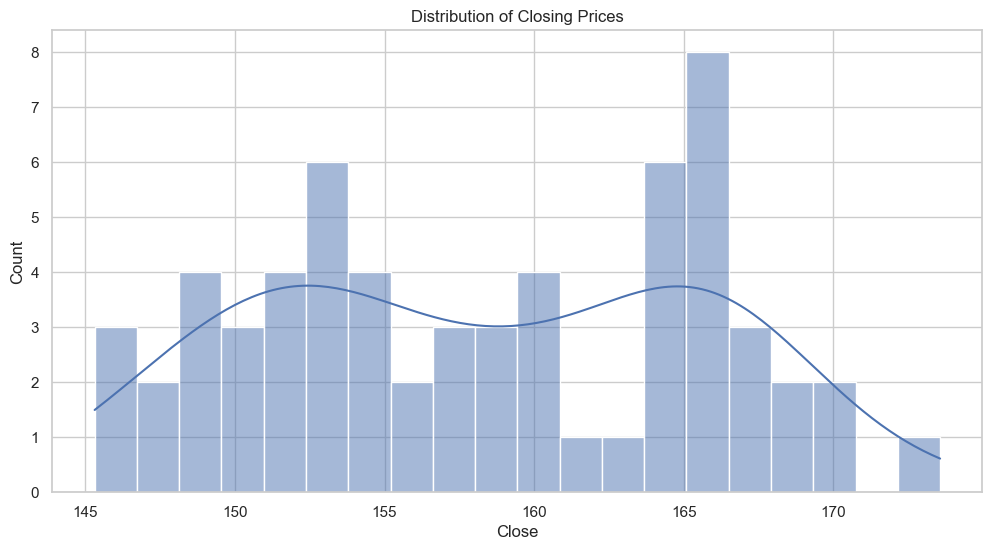

In [34]:
sns.histplot(df['Close'], bins=20, kde=True)
plt.title('Distribution of Closing Prices')

### 18. Q: How do you change the figure size of your plots to make them bigger?

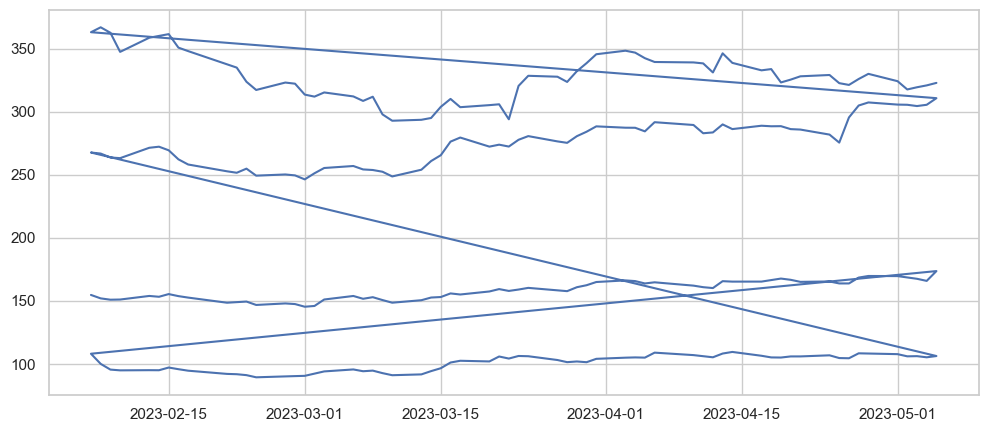

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'])

### 19. Q: How do you save your current plot as an image file (PNG)?

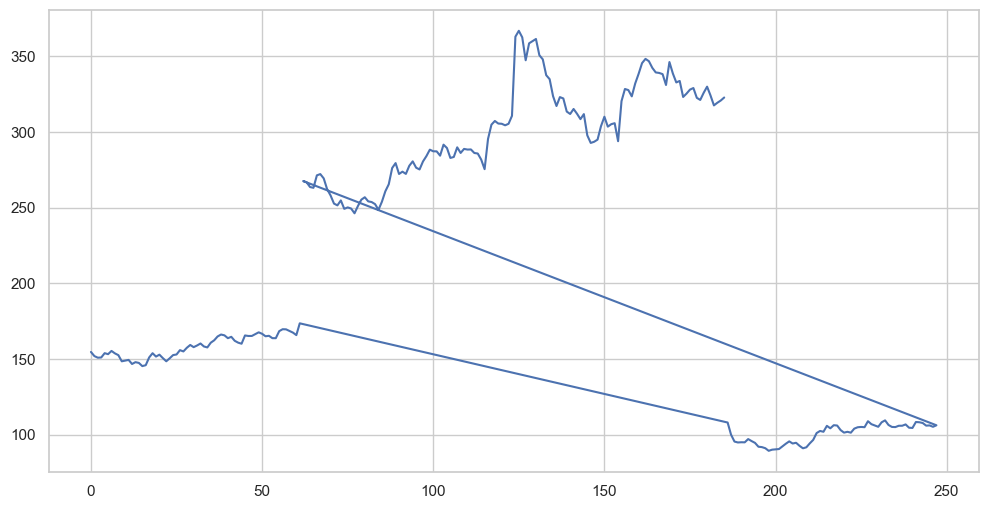

In [23]:
plt.plot(df['Close'])
plt.savefig('my_stock_plot.png')

### 20 Q: Calculate Daily Returns & Volatility (Risk Analysis)
 High volatility suggests high risk. We use standard deviation of returns to measure this.

Annualized Volatility (Risk Profile):
Ticker
NFLX    0.356880
GOOG    0.328764
MSFT    0.283849
AAPL    0.224660
Name: Daily_Return, dtype: float64


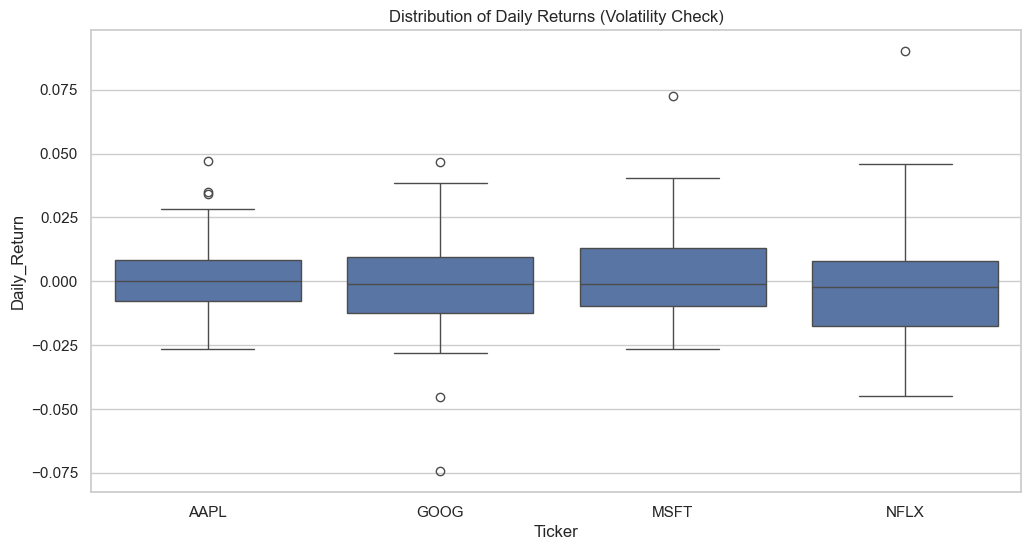

In [6]:
df['Daily_Return'] = df.groupby('Ticker')['Close'].pct_change()


volatility = df.groupby('Ticker')['Daily_Return'].std() * np.sqrt(252)
print("Annualized Volatility (Risk Profile):")
print(volatility.sort_values(ascending=False))


sns.boxplot(data=df, x='Ticker', y='Daily_Return')
plt.title('Distribution of Daily Returns (Volatility Check)')
plt.show()

### 21 Q: Identify Golden Cross (Moving Average Crossover)
When a short-term MA (50 days) crosses a long-term MA (200 days), it's a "Buy" signal.

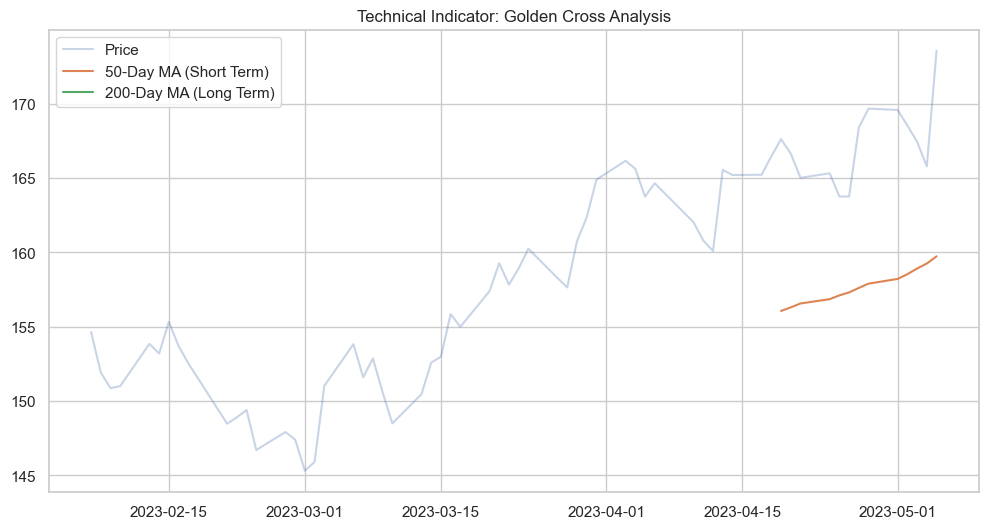

In [7]:
df['MA50'] = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=50).mean())
df['MA200'] = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=200).mean())


aapl = df[df['Ticker'] == 'AAPL']
plt.plot(aapl['Date'], aapl['Close'], label='Price', alpha=0.3)
plt.plot(aapl['Date'], aapl['MA50'], label='50-Day MA (Short Term)')
plt.plot(aapl['Date'], aapl['MA200'], label='200-Day MA (Long Term)')
plt.title('Technical Indicator: Golden Cross Analysis')
plt.legend()
plt.show()

### 22 Q: Correlation Matrix (Portfolio Diversification)
 A portfolio manager wants stocks with LOW correlation to reduce systemic risk.

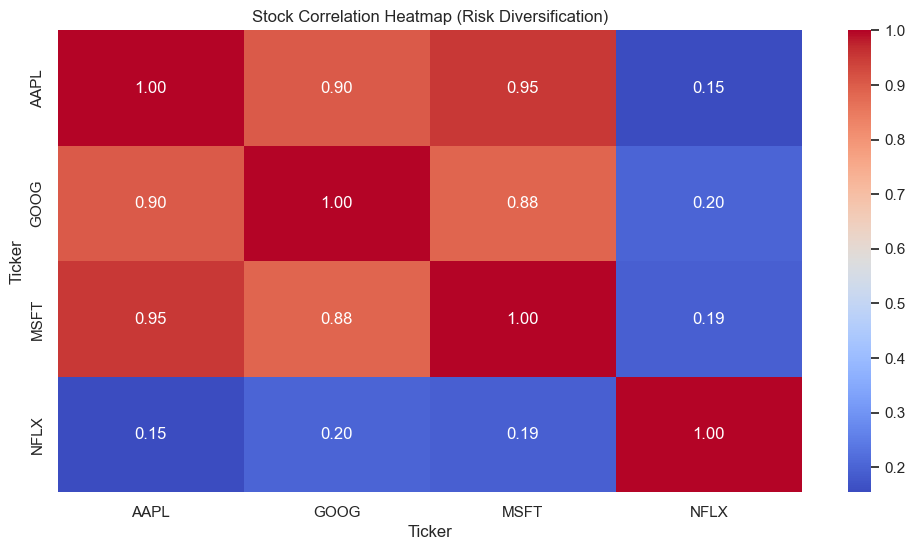

In [8]:
pivot_df = df.pivot(index='Date', columns='Ticker', values='Close')

corr_matrix = pivot_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Stock Correlation Heatmap (Risk Diversification)')
plt.show()

### 23 Q: Cumulative Returns (Investment Growth)
This shows how an initial investment grows over time, including compounding effects.

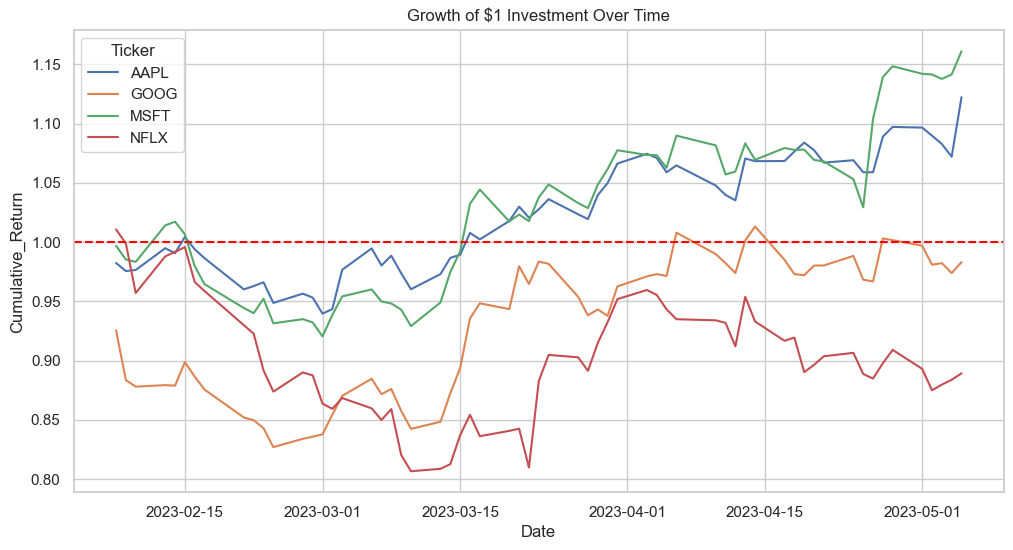

In [9]:
df['Cumulative_Return'] = (1 + df['Daily_Return']).groupby(df['Ticker']).cumprod()

sns.lineplot(data=df, x='Date', y='Cumulative_Return', hue='Ticker')
plt.axhline(1, color='red', linestyle='--') # Baseline
plt.title('Growth of $1 Investment Over Time')
plt.show()

### 24. Q How did you implement a Trend-Following Strategy using Exponential Moving Averages (EMA) ?

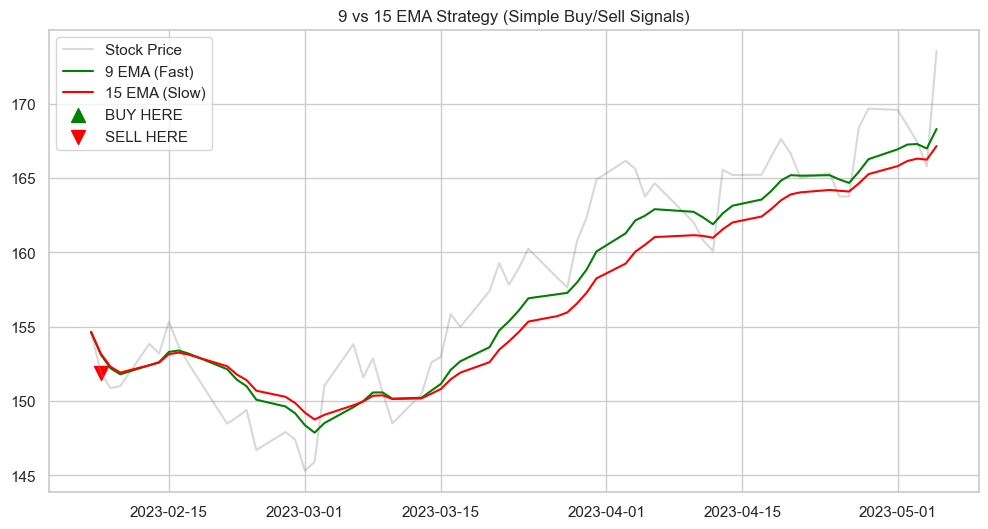

In [24]:
df = df[df['Ticker'] == 'AAPL'] 
#EMA calculate
df['EMA9'] = df['Close'].ewm(span=9).mean()
df['EMA15'] = df['Close'].ewm(span=15).mean()

# 3. Buy/Sell 
# EMA9 > EMA15 -> Buy (Signal = 1)
# EMA9 < EMA15 -> Sell (Signal = -1)
df['Signal'] = 0
df.loc[df['EMA9'] > df['EMA15'], 'Signal'] = 1
df.loc[df['EMA9'] < df['EMA15'], 'Signal'] = -1
df['Action'] = df['Signal'].diff() 

#4. Graph
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label='Stock Price', color='gray', alpha=0.3)
plt.plot(df['Date'], df['EMA9'], label='9 EMA (Fast)', color='green')
plt.plot(df['Date'], df['EMA15'], label='15 EMA (Slow)', color='red')

# Buy signal on the graph (Green Arrow)
buy_points = df[df['Action'] == 1]
plt.scatter(buy_points['Date'], buy_points['Close'], marker='^', color='green', s=100, label='BUY HERE')

# Sell signal on the graph (Red Arrow)
sell_points = df[df['Action'] == -1]
plt.scatter(sell_points['Date'], sell_points['Close'], marker='v', color='red', s=100, label='SELL HERE')

plt.title('9 vs 15 EMA Strategy (Simple Buy/Sell Signals)')
plt.legend()
plt.show()